# TED Talks — Theme Refinement & Preprocessing Merge (Week 3)

**What this notebook does:**
1. Splits the oversized `society` theme into two more focused themes (`politics_governance` and `culture_society`) → 6 themes total
2. Resolves the multi-label overlap by assigning each talk to a **single** theme using a *rarest-tag-wins* rule
3. Applies Camilla's preprocessing pipeline (spaCy lemmatisation, stopword removal) to the `description` column
4. Produces the final master dataset for sentiment analysis

Remark
- The week-2 `society` theme had 1,318 talks vs only 251 for `education` — a 5× imbalance that would distort group-level sentiment comparisons.
- 36% of talks were tagged with multiple themes simultaneously, violating the independence assumption of most statistical tests we want to run later.

**Inputs**: ../data/ted_cleaned_with_themes.csv

**Outputs**: `../data/ted_master.csv`

## 1. Setup

In [9]:
!pip install spacy nltk
!python -m spacy download en_core_web_sm


[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 16.2 MB/s eta 0:00:00 0:00:01

[notice] A new release of pip is available: 24.3.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [10]:
import ast
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_style('whitegrid')

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

SKIP_PREPROCESSING = False

import zipfile

zip_path = DATA_DIR / 'ted_cleaned_with_themes.csv.zip'


with zipfile.ZipFile(zip_path, 'r') as z:
    with z.open('ted_cleaned_with_themes.csv') as f:
        df = pd.read_csv(f)

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns')


Loaded 2,453 rows × 28 columns


In [11]:
# Re-parse tags column
def parse_tags(val):
    if pd.isna(val):
        return []
    try:
        return ast.literal_eval(val)
    except (ValueError, SyntaxError):
        return []

df['tags_list'] = df['tags'].apply(parse_tags)
print('Tags parsed.')

Tags parsed.


## 2. Refined theme groups (6 themes)

**Society split rationale.** The original `society` theme bundled 18 different tags spanning everything from `politics` and `war` to `culture` and `religion`. We split it along the institutional/cultural axis:

- **politics_governance** — formal/political domain: governments, conflicts, global affairs, activism
- **culture_society** — informal/social domain: culture, community, identity, social problems

All other themes are unchanged from week 2.

In [12]:
THEME_GROUPS = {
    'education': [
        'education', 'children', 'parenting',
    ],
    'psychology': [
        'psychology', 'brain', 'neuroscience', 'mind', 'mental health',
        'cognitive science', 'happiness', 'personal growth', 'identity',
    ],
    'politics_governance': [
        'politics', 'government', 'war', 'peace',
        'global development', 'global issues', 'activism',
    ],
    'culture_society': [
        'society', 'culture', 'social change', 'humanity', 'community',
        'women', 'inequality', 'religion', 'poverty', 'violence', 'social media',
    ],
    'environment': [
        'environment', 'nature', 'animals', 'climate change', 'sustainability',
        'oceans', 'green', 'biodiversity', 'ecology', 'energy',
    ],
    'business': [
        'business', 'economics', 'entrepreneur', 'work', 'innovation',
    ],
}

TAG_TO_THEME = {tag: theme for theme, tags in THEME_GROUPS.items() for tag in tags}
print(f'{len(TAG_TO_THEME)} tags assigned across {len(THEME_GROUPS)} themes')

45 tags assigned across 6 themes


## 3. Multi-label theme assignment (intermediate)

First we recompute the multi-label themes (a talk can belong to multiple themes), as in week 2. We need this to apply the rarest-tag-wins rule in the next step.

In [13]:
def themes_for(tags_list):
    return sorted({TAG_TO_THEME[t] for t in tags_list if t in TAG_TO_THEME})

df['themes_multi'] = df['tags_list'].apply(themes_for)
df['num_themes_multi'] = df['themes_multi'].apply(len)

print('Multi-label theme distribution:')
for theme in THEME_GROUPS:
    n = df['themes_multi'].apply(lambda lst: theme in lst).sum()
    print(f'  {theme:<20} {n:>5,}')
print(f'\n  {"unclassified":<20} {(df["num_themes_multi"] == 0).sum():>5,}')

Multi-label theme distribution:
  education              251
  psychology             462
  politics_governance    718
  culture_society      1,019
  environment            425
  business               630

  unclassified           481


## 4. Rarest-tag-wins single-label assignment

**The rule:**
- If a talk falls into 0 themes → mark as `unclassified` (we'll exclude these from group analysis)
- If a talk falls into exactly 1 theme → assign that theme
- If a talk falls into 2+ themes → assign whichever of those themes is **rarest in the corpus**

**Reason** Smaller themes (`education`, `psychology`) are at risk of being drained because their typical talks are often co-tagged with bigger themes (`culture_society`). Letting the rarest theme win protects the small themes' samples and keeps the groups more balanced.

We compute theme rarity from the multi-label counts above (so the priority order is fixed before assignment).

In [14]:
# Compute theme priority: rarest first (lowest multi-label count → highest priority)
theme_size = {
    theme: int(df['themes_multi'].apply(lambda lst: theme in lst).sum())
    for theme in THEME_GROUPS
}
theme_priority = sorted(theme_size, key=theme_size.get)  # ascending → rarest first

print('Theme priority (rarest wins):')
for i, theme in enumerate(theme_priority, 1):
    print(f'  {i}. {theme:<20} ({theme_size[theme]:,} talks)')

Theme priority (rarest wins):
  1. education            (251 talks)
  2. environment          (425 talks)
  3. psychology           (462 talks)
  4. business             (630 talks)
  5. politics_governance  (718 talks)
  6. culture_society      (1,019 talks)


In [15]:
def assign_single_theme(theme_set, priority=theme_priority):
    if not theme_set:
        return 'unclassified'
    # Pick the theme that comes first in priority (= rarest)
    for theme in priority:
        if theme in theme_set:
            return theme
    return 'unclassified'  # safety fallback

df['theme'] = df['themes_multi'].apply(lambda lst: assign_single_theme(set(lst)))

print('Single-label theme distribution:')
print(df['theme'].value_counts())

Single-label theme distribution:
theme
unclassified           481
environment            401
business               385
psychology             352
politics_governance    331
culture_society        252
education              251
Name: count, dtype: int64


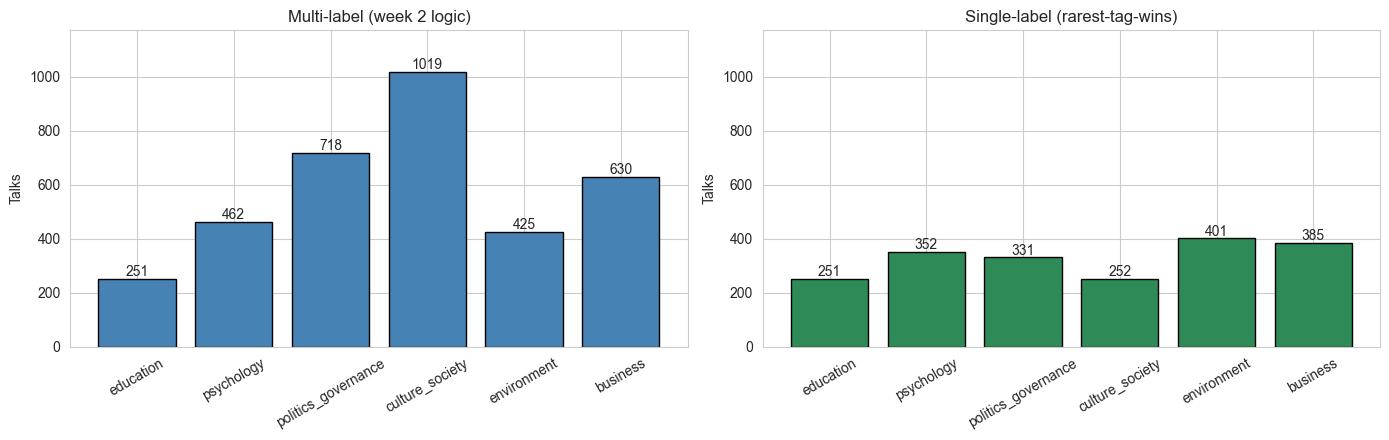

In [16]:
# Visualise the change: multi-label vs single-label
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

themes_only = list(THEME_GROUPS)
multi_counts = pd.Series(theme_size).reindex(themes_only)
single_counts = df['theme'].value_counts().reindex(themes_only).fillna(0).astype(int)

axes[0].bar(multi_counts.index, multi_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Multi-label (week 2 logic)')
axes[0].set_ylabel('Talks')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(multi_counts.values):
    axes[0].text(i, v + 10, str(int(v)), ha='center')

axes[1].bar(single_counts.index, single_counts.values, color='seagreen', edgecolor='black')
axes[1].set_title('Single-label (rarest-tag-wins)')
axes[1].set_ylabel('Talks')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(single_counts.values):
    axes[1].text(i, v + 10, str(int(v)), ha='center')

for ax in axes:
    ax.set_ylim(0, max(multi_counts.max(), single_counts.max()) * 1.15)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theme_assignment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Quick validation

Two sanity checks before saving:
1. Group sizes — are they balanced enough for sentiment comparison?
2. The unclassified bucket — what does it contain?

In [17]:
# (1) Balance: ratio of biggest to smallest theme (excluding unclassified)
theme_only = df[df['theme'] != 'unclassified']
sizes = theme_only['theme'].value_counts()
print(f'Largest theme:  {sizes.idxmax():<22} {sizes.max():,}')
print(f'Smallest theme: {sizes.idxmin():<22} {sizes.min():,}')
print(f'Imbalance ratio: {sizes.max() / sizes.min():.1f}x  (was 5.3x with old society theme)')

Largest theme:  environment            401
Smallest theme: education              251
Imbalance ratio: 1.6x  (was 5.3x with old society theme)


In [18]:
# (2) What's in the unclassified bucket?
unclassified = df[df['theme'] == 'unclassified']
uncl_tags = pd.Series([t for tl in unclassified['tags_list'] for t in tl]).value_counts()
print(f'{len(unclassified)} unclassified talks; their top 10 tags:')
print(uncl_tags.head(10))

481 unclassified talks; their top 10 tags:
technology       196
design           132
entertainment    100
science          100
art               79
TEDx              67
music             66
creativity        62
performance       44
TED Fellows       41
Name: count, dtype: int64


## 6. Save the themed dataset (intermediate)

We save the data with the refined themes here, before adding the preprocessing column. This is useful if anyone needs the themed data without spaCy installed.

In [19]:
# Drop the helper list-typed columns before saving
to_save = df.drop(columns=['tags_list', 'themes_multi'], errors='ignore').copy()

intermediate_path = DATA_DIR / 'ted_themes_v2.csv'
to_save.to_csv(intermediate_path, index=False)
print(f'Saved -> {intermediate_path}')
print(f'   {len(to_save):,} rows × {to_save.shape[1]} columns')
print(f'   New column: theme (single-label, 6 themes + unclassified)')

Saved -> ../data/ted_themes_v2.csv
   2,453 rows × 30 columns
   New column: theme (single-label, 6 themes + unclassified)


## 7. Apply Camilla's preprocessing pipeline

This applies the same preprocessing Camilla used in `preprocessing_pipeline.ipynb`:
spaCy lemmatisation, lowercasing, stopword and punctuation removal.

We apply it to the `description` column to match Camilla's choice. The output column is called `clean_text` and contains a list of token strings, identical in structure to her output.

> **Note for the team**: For sentiment analysis on the actual TED talk content, the `transcript` column would normally be a more natural choice than `description`. Worth a quick group discussion before sentiment analysis runs.

In [20]:
if SKIP_PREPROCESSING:
    print('SKIP_PREPROCESSING is True — skipping spaCy step.')
    print('Set SKIP_PREPROCESSING = False at the top of this notebook to run preprocessing locally.')
else:
    import nltk
    import spacy
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
    nlp = spacy.load('en_core_web_sm')
    print('spaCy + NLTK ready')

spaCy + NLTK ready


[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1077)>


In [21]:
def preprocess(text):
    """Camilla's pipeline: spaCy lemmatisation + lowercasing + stopword/punct/space removal."""
    doc = nlp(str(text))
    return [
        token.lemma_.lower()
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]

if not SKIP_PREPROCESSING:
    print(f'Preprocessing {len(df):,} descriptions...')
    df['clean_text'] = df['description'].apply(preprocess)
    print('Done.')
    print('\nSample:')
    print(df[['name', 'clean_text']].head(3).to_string())

Preprocessing 2,453 descriptions...
Done.

Sample:
                                        name                                                                                                                                                                            clean_text
0  Ken Robinson: Do schools kill creativity?                                                         [sir, ken, robinson, make, entertaining, profoundly, moving, case, create, education, system, nurture, undermine, creativity]
1       Al Gore: Averting the climate crisis  [humor, humanity, exude, inconvenient, truth, al, gore, spell, 15, way, individual, address, climate, change, immediately, buy, hybrid, invent, new, hotter, brand, global, warming]
2              David Pogue: Simplicity sells          [new, york, times, columnist, david, pogue, take, aim, technology, bad, interface, design, offender, provide, encourage, example, product, right, funny, thing, burst, song]


## 8. Save the final master dataset

In [22]:
if not SKIP_PREPROCESSING:
    final = df.drop(columns=['tags_list', 'themes_multi'], errors='ignore').copy()
    final_path = DATA_DIR / 'ted_master.csv'
    final.to_csv(final_path, index=False)
    print(f'Saved -> {final_path}')
    print(f'   {len(final):,} rows × {final.shape[1]} columns')
    print('   Includes: theme (6 themes + unclassified), clean_text (preprocessed tokens)')
else:
    print('Preprocessing was skipped, so ted_master.csv was NOT produced.')
    print('To produce the final master CSV:')
    print('  1. Make sure spaCy and en_core_web_sm are installed locally')
    print('  2. Set SKIP_PREPROCESSING = False at the top of this notebook')
    print('  3. Re-run all cells')
    print()
    print('In the meantime, ted_themes_v2.csv has the refined themes (without clean_text).')

Saved -> ../data/ted_master.csv
   2,453 rows × 31 columns
   Includes: theme (6 themes + unclassified), clean_text (preprocessed tokens)
